In [1]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

import pandas as pd
from PIL import Image
import io
import math

def show_png(data):
    bio = io.BytesIO(data)
    img = Image.open(bio)
    return img

In [2]:
# a function to convert bit information to SMARTS substructures for a given molecule

def bitinfo_to_smarts(bitinfo, mol):
    bit2smarts = {}
    for bit, info in bitinfo.items():
        bit2smarts[bit] = set()
        for atom_id, radius in info:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)
            atomsToUse = set((atom_id, ))
            for b in env:
                atomsToUse.add(mol.GetBondWithIdx(b).GetBeginAtomIdx())
                atomsToUse.add(mol.GetBondWithIdx(b).GetEndAtomIdx())

            enlargedEnv = set()
            for atom in atomsToUse:
                a = mol.GetAtomWithIdx(atom)
                for b in a.GetBonds():
                    bidx = b.GetIdx()
                    if bidx not in env:
                        enlargedEnv.add(bidx)

            enlargedEnv = list(enlargedEnv)
            enlargedEnv += env

            # find all relevant neighbors
            anyAtoms = []
            for a in atomsToUse:
                neighbors = mol.GetAtomWithIdx(a).GetNeighbors()
                for n in neighbors:
                    anyIdx = n.GetIdx()
                    if anyIdx not in atomsToUse:
                        anyAtoms.append(anyIdx)

            # replace atomic number to zero (there is no number for any atom)
            # have to make a sacrificial copy of the molecule here
            alt_mol = Chem.Mol(mol)
            for aA in anyAtoms:
                alt_mol.GetAtomWithIdx(aA).SetAtomicNum(0)

            submol = Chem.PathToSubmol(alt_mol, enlargedEnv)
            del alt_mol

            # change [0] to *
            morgan_bit_smarts = Chem.MolToSmarts(submol).replace('[#0]', '*')
            bit2smarts[bit].add(morgan_bit_smarts)
    return bit2smarts



In [3]:
df = pd.read_csv('AqSolDB_v1.0_min.csv', index_col="ID")
df['mol'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
df = df[df['mol'].notna()]
df

,Name,InChIKey,SMILES,Solubility,mol
ID,,,,,
A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x76f66e131c40>
A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x76f66e131cb0>
A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x76f66e131d20>
A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x76f66e131d90>
A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x76f66e131e00>
...,...,...,...,...,...
I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x76f66ed6cf20>
I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x76f66ed6cf90>
I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x76f66ed6d000>


In [4]:
bit2substructure = [set() for _ in range(2048)]
substructure2count = {}

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2)
fpgen_meta = rdFingerprintGenerator.AdditionalOutput()
fpgen_meta.AllocateBitInfoMap()

for i, row in df.iterrows():
    mol = row['mol']
    fp = fpgen.GetFingerprint(mol, additionalOutput=fpgen_meta)
    meta = fpgen_meta.GetBitInfoMap()
    for bit, smarts in bitinfo_to_smarts(meta, mol).items():
        bit2substructure[bit].update(smarts)
        for expr in smarts:
            substructure2count[expr] = substructure2count.get(expr, 0) + 1

print(bit2substructure[42])

{'*-[#6](-[#6](=[#8])-[#8]-[#6])-*', '[#6]-[#6]-[#6](-[#6])-[#6](-*)-*', '[#6]-[#8]-[#6](=[#8])-[#6](-*)-*', '*-[#6]-[#8]-[#6](-[#8]-[#6]-*)-[#6](-[#17])(-[#17])-[#17]', '[#6]-[#8]-[#6](=[#8])-[#6@H](-*)-[#0@H]', '*-[#6@H](-[#0@@H])-[#6@H](-[#8]-*)-[#6@@H](-[#8]-[#6](-*)=*)-[#6]=[#8]', '[#6]-[#8]-[#6](=[#8])-[#6@@H](-[#0@H])-*', '*-[#6]-[#6](-[#8]-[#6](=[#8])-[#6](-*)-*)-[#6](-*)(-*)-*', '*-[#8]-[#6]-[#6](-[#6]-[#8])(-[#6]-[#8])-[#6]-[#8]', '[#6]-[#16]-[#6]-[#8]-*', '[#6]-[#6](-[#6])-[#6](-[#6])(-[#6]-*)-[#6]-*', '[#6](-[#6@H](-[#0@@H])-[#0@H])(=[#8])-[#8]-[#6]', '*-[#6](-*)-[#6](=[#8])-[#8]-[#6]', '*-[#6]1:*:[#6]:[#6]2-[#6]-[#8]-[#6](=[#8])-[#6]:2:[#6]:1-[#8]-*', '*:[#16]:[#6](:[#6](:*)-*)-[#6]-*', '*-[#6@@H](-[#0@H])-[#6](=[#8])-[#8]-[#6]', '[#8]-[#6]-[#6](-[#6]-[#8])(-[#6]-[#8])-[#6]-[#8]-*', '*-[#6]-[#6](=[#8])-[#8]-[#8]-[#6](=*)-*', '[#6]-[#8]-[#6](=[#8])-[#6@H](-*)-*', '*-[#6](=*)-[#8]-[#8]-[#6](=[#8])-[#6]-*'}


In [5]:
print(substructure2count['*-[#6]-[#6]-[#6]-*'])
print(substructure2count['*:[#6]:[#6]:[#6]:*'])
print(substructure2count['*:[#6]:[#7]:[#6]:*'])

1730
2813
200


In [6]:
# I will use counts and rarity to create weights for the fragments
# You will use the SHAP values tied to the fragments, or anything you can come up with

substructure2rarity = {expr: 1 / count for expr, count in substructure2count.items()}

In [7]:
substructures_by_rarity = sorted(substructure2rarity.items(), key=lambda x: x[1])
print(f"most common substructure: {substructures_by_rarity[0]}")
print(f"least common substructure: {substructures_by_rarity[-1]}")


most common substructure: ('*-[#6]-*', 0.00015625)
least common substructure: ('*:[#6]:[#6](-[#6]-[#6]-[#7](-*)-*):[#6]:*', 1.0)


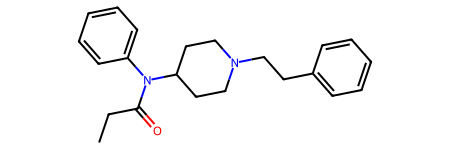

In [8]:
# lets make a random structure to test atom contribution visualization
fentanyl = Chem.MolFromSmiles('CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3')
fentanyl

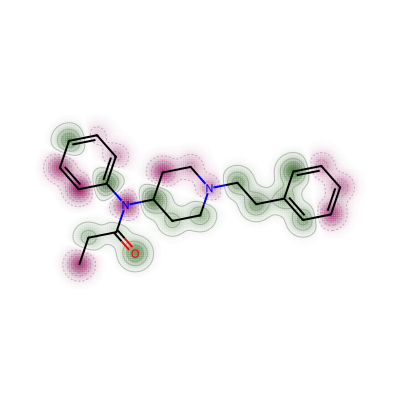

In [9]:
# lets try random hightlights for individual atoms
import random
d = Draw.MolDraw2DCairo(400, 400)
SimilarityMaps.GetSimilarityMapFromWeights(fentanyl,[((random.randrange(0, 200) - 100) / 100.0) for atom in fentanyl.GetAtoms()],draw2d=d)
d.FinishDrawing()
show_png(d.GetDrawingText())

[67.37092980461367, 250.60077745882134, 398.08554453855476, 182.11840908658027, 576.1731133210585, 579.5025091812979, 407.45004955987923, 307.6370573060997, 291.3769062536654, 307.6370573060997, 407.45004955987923, 184.56233981460363, 129.67829805470848, 72.5765886660158, 41.863588227360566, 29.263353863498903, 25.3452868920175, 29.263353863498903, 41.863588227360566, 336.415610675992, 171.73888811223068, 73.83507138028891, 51.158371067316516, 73.83507138028891, 171.73888811223068]
[160, 572, 890, 392, 1295, 1270, 844, 641, 659, 641, 844, 416, 302, 226, 153, 113, 106, 113, 153, 789, 434, 225, 167, 225, 434]
[0.4210683112788354, 0.4381132473056317, 0.44728712869500536, 0.4645877782820925, 0.44492132302784443, 0.4563011883317306, 0.48276072222734506, 0.4799330067177842, 0.442150085362163, 0.4799330067177842, 0.48276072222734506, 0.4436594707081818, 0.4293983379294983, 0.3211353480797159, 0.273618223708239, 0.25896773330530004, 0.23910648011337265, 0.25896773330530004, 0.273618223708239, 

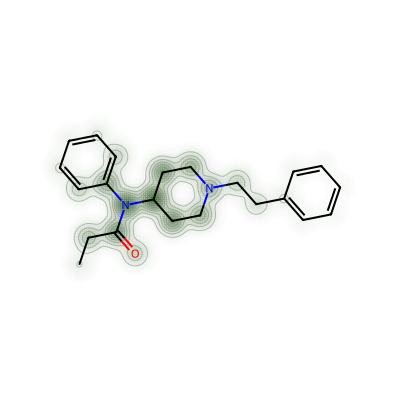

In [10]:
# lets try the same with fragment contribution from substructures by rarity
# -> highlight the average rarity of each part of the molecule

# lets convert the the substructures to rdkit mol queries
query2contribution = {Chem.MolFromSmarts(smarts): rarity for smarts, rarity in substructure2rarity.items()}

# now query the molecule for each fragment, add the rarity of each hit fragment to all the atoms in the molecule that the fragment touches
# -> this will give us the cumulative rarity of each atom

# make a list to collect the cumulative rarity for each atom
cumulative_rarity = [0.0 for _ in fentanyl.GetAtoms()]
cumulative_hit_counts = [0 for _ in fentanyl.GetAtoms()]

# iterate over the fragments and add the rarity to the atoms that the fragment touches
for query, contribution in query2contribution.items():
    matches = fentanyl.GetSubstructMatches(query)
    for match in matches:
        for atom_id in match:
            cumulative_rarity[atom_id] += contribution
            cumulative_hit_counts[atom_id] += 1

print(cumulative_rarity)  # you will probably use some sort of cumulative value of SHAP, being hit by multiple queries should intuitively add to the weight
print(cumulative_hit_counts)

average_rarity = [rarity / hit_count for rarity, hit_count in zip(cumulative_rarity, cumulative_hit_counts)]
print(average_rarity) # averages are also possible, depends on what you want to show

# now we can visualize the cumulative rarity of each atom
d = Draw.MolDraw2DCairo(400, 400)
SimilarityMaps.GetSimilarityMapFromWeights(fentanyl, cumulative_rarity, draw2d=d)
d.FinishDrawing()
show_png(d.GetDrawingText())






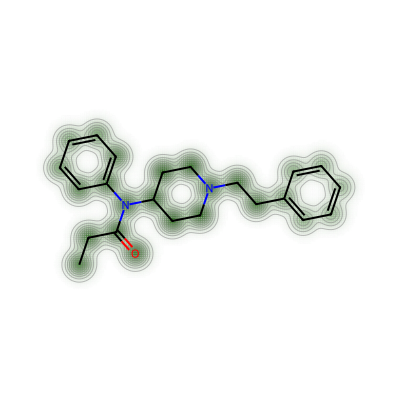

In [11]:
# same for average rarity of each atom
d = Draw.MolDraw2DCairo(400, 400)
SimilarityMaps.GetSimilarityMapFromWeights(fentanyl, average_rarity, draw2d=d)
d.FinishDrawing()
show_png(d.GetDrawingText())

In [12]:
# lets try to wrap the weight creation into a function

def create_weight_contribution(mol, query2contribution):
    cumulative_weights = [0.0 for _ in mol.GetAtoms()]
    hit_counts = [0 for _ in mol.GetAtoms()]
    for query, contribution in query2contribution.items():
        matches = mol.GetSubstructMatches(query)
        for match in matches:
            for atom_id in match:
                cumulative_weights[atom_id] += contribution
                hit_counts[atom_id] += 1
    return cumulative_weights, hit_counts

# lets try it out
cumulative_weights = create_weight_contribution(fentanyl, query2contribution)
print(cumulative_weights)

# and the averaging as well
def average_weights(mol, query2contribution):
    cumulative_weights, hit_counts = create_weight_contribution(mol, query2contribution)
    return [weight / hit_count for weight, hit_count in zip(cumulative_weights, hit_counts)]

# lets try it out
print(average_weights(fentanyl, query2contribution))



([67.37092980461367, 250.60077745882134, 398.08554453855476, 182.11840908658027, 576.1731133210585, 579.5025091812979, 407.45004955987923, 307.6370573060997, 291.3769062536654, 307.6370573060997, 407.45004955987923, 184.56233981460363, 129.67829805470848, 72.5765886660158, 41.863588227360566, 29.263353863498903, 25.3452868920175, 29.263353863498903, 41.863588227360566, 336.415610675992, 171.73888811223068, 73.83507138028891, 51.158371067316516, 73.83507138028891, 171.73888811223068], [160, 572, 890, 392, 1295, 1270, 844, 641, 659, 641, 844, 416, 302, 226, 153, 113, 106, 113, 153, 789, 434, 225, 167, 225, 434])
[0.4210683112788354, 0.4381132473056317, 0.44728712869500536, 0.4645877782820925, 0.44492132302784443, 0.4563011883317306, 0.48276072222734506, 0.4799330067177842, 0.442150085362163, 0.4799330067177842, 0.48276072222734506, 0.4436594707081818, 0.4293983379294983, 0.3211353480797159, 0.273618223708239, 0.25896773330530004, 0.23910648011337265, 0.25896773330530004, 0.27361822370823

In [13]:
# we can also make the visualization into a function
def visualize_weights(mol, weights, draw_size=600):
    d = Draw.MolDraw2DCairo(draw_size, draw_size)
    SimilarityMaps.GetSimilarityMapFromWeights(mol, weights, draw2d=d)
    d.FinishDrawing()
    return show_png(d.GetDrawingText())



In [14]:
gusperimus = Chem.MolFromSmiles('N=C(N)NCCCCCCC(=O)NC(O)C(=O)NCCCCNCCCN')
gusperimus_weights, gusperimus_hit_counts = create_weight_contribution(gusperimus, query2contribution)
print(gusperimus_weights)
print(gusperimus_hit_counts)


[21.991993483343492, 41.660262522292115, 26.207494123898222, 43.04736919385307, 41.04382408028087, 37.88300079225941, 36.53485861938205, 48.47926038652551, 71.65180683706123, 119.65496732369581, 148.21398037297092, 80.896051237199, 173.2103385957409, 196.27300996670502, 76.52624244831567, 175.32568430852183, 71.28270353554382, 126.55953654536904, 91.52906430649604, 63.240510839596865, 54.48807141732821, 44.49475052055374, 39.9591707811032, 37.02490432482388, 28.482104681875043, 17.278711480257805, 6.106650848178024]
[62, 118, 73, 140, 136, 148, 152, 194, 233, 355, 409, 227, 473, 517, 207, 460, 184, 339, 252, 178, 151, 132, 123, 104, 81, 58, 29]


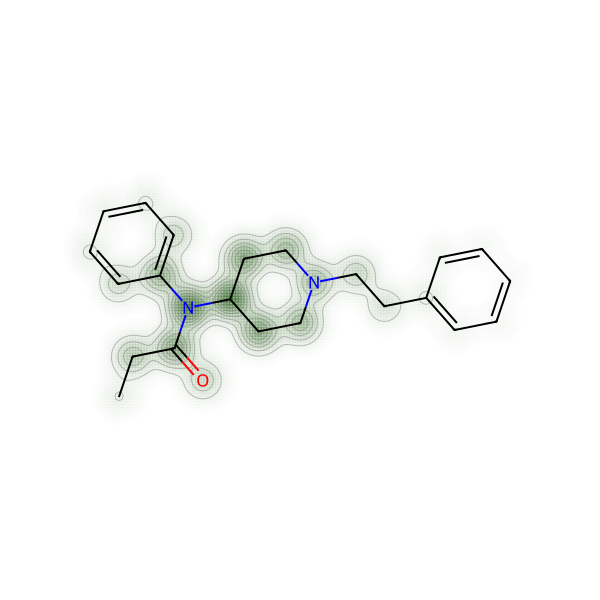

In [15]:
# now to tie it all together
visualize_weights(fentanyl, create_weight_contribution(fentanyl, query2contribution)[0])


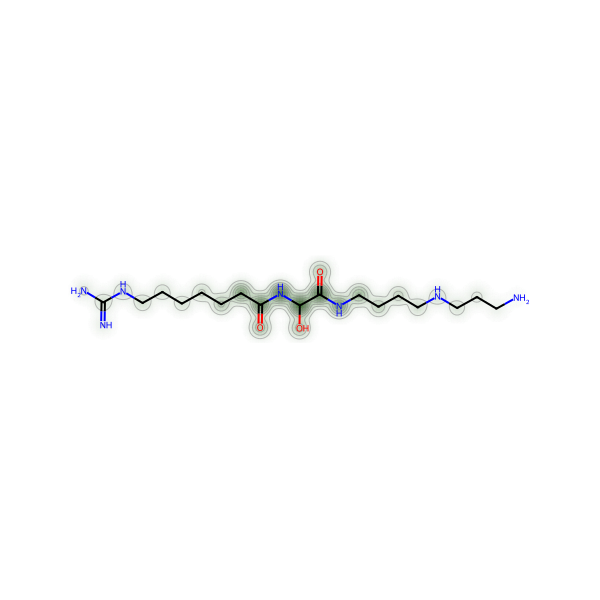

In [16]:
visualize_weights(gusperimus, create_weight_contribution(gusperimus, query2contribution)[0])